# NOTEBOOK: Clustering Model Comparison

Compare all clustering models on Customer Segmentation dataset:
 - K-Means Clustering
 - DBSCAN
 - Hierarchical Clustering

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader
from src.preprocessing import DataPreprocessor
from src.models.unsupervised import (
    SKLearnKMeans,
    SKLearnDBSCAN,
    SKLearnHierarchicalClustering,
    SKLearnPCA
)

2025-12-31 00:34:26.600153: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load & Preprocess Data

In [2]:
X = data_loader.load_customer_segmentation()

# Preprocess (scaling critical for clustering!)
preprocessor = DataPreprocessor(scale=True, encode_categorical=False)
X_scaled = preprocessor.fit_transform(X)

print(f"Dataset: {X_scaled.shape}")


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 3 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 3 features

Final shape: 200 rows × 3 features

Dataset: (200, 3)


## Find Optimal Parameters


Finding optimal parameters...
FINDING OPTIMAL NUMBER OF CLUSTERS

Testing k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Method: both

k= 2: Inertia=  389.39, Silhouette=0.3355
k= 3: Inertia=  295.46, Silhouette=0.3579
k= 4: Inertia=  205.23, Silhouette=0.4040
k= 5: Inertia=  169.89, Silhouette=0.4085
k= 6: Inertia=  134.35, Silhouette=0.4311
k= 7: Inertia=  121.39, Silhouette=0.4101
k= 8: Inertia=  113.73, Silhouette=0.3674
k= 9: Inertia=  102.14, Silhouette=0.3744
k=10: Inertia=   92.55, Silhouette=0.3619

💡 Elbow method suggests: k=4
💡 Silhouette method suggests: k=6 (score: 0.4311)

⚠️  Methods disagree (Elbow: k=4, Silhouette: k=6)
   → Recommending k=6 (Silhouette is more reliable)


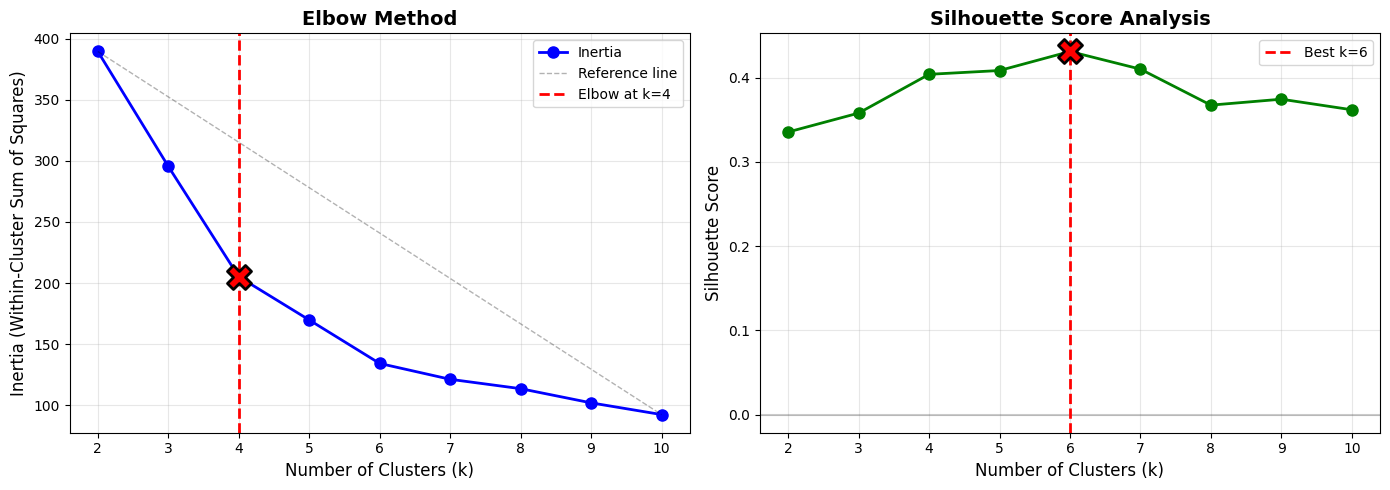

  K-Means optimal k: 6
FINDING OPTIMAL EPS FOR DBSCAN

Testing eps values: [0.1 0.2 0.3 0.4 0.5]...[1.5 1.6 1.7 1.8 1.9]
Using min_samples: 5

eps=0.10: 0 clusters, 200 noise
eps=0.20: 1 clusters, 195 noise
eps=0.30: 10 clusters, 134 noise, silhouette=0.5144
eps=0.40: 6 clusters, 98 noise, silhouette=0.5190
eps=0.50: 6 clusters, 60 noise, silhouette=0.4817
eps=0.60: 2 clusters, 28 noise, silhouette=0.2730
eps=0.70: 1 clusters, 14 noise
eps=0.80: 1 clusters, 6 noise
eps=0.90: 1 clusters, 3 noise
eps=1.00: 1 clusters, 2 noise
eps=1.10: 1 clusters, 0 noise
eps=1.20: 1 clusters, 0 noise
eps=1.30: 1 clusters, 0 noise
eps=1.40: 1 clusters, 0 noise
eps=1.50: 1 clusters, 0 noise
eps=1.60: 1 clusters, 0 noise
eps=1.70: 1 clusters, 0 noise
eps=1.80: 1 clusters, 0 noise
eps=1.90: 1 clusters, 0 noise

💡 Optimal eps: 0.40
   Clusters: 6
   Noise points: 98 (49.0%)
   Silhouette score: 0.5190


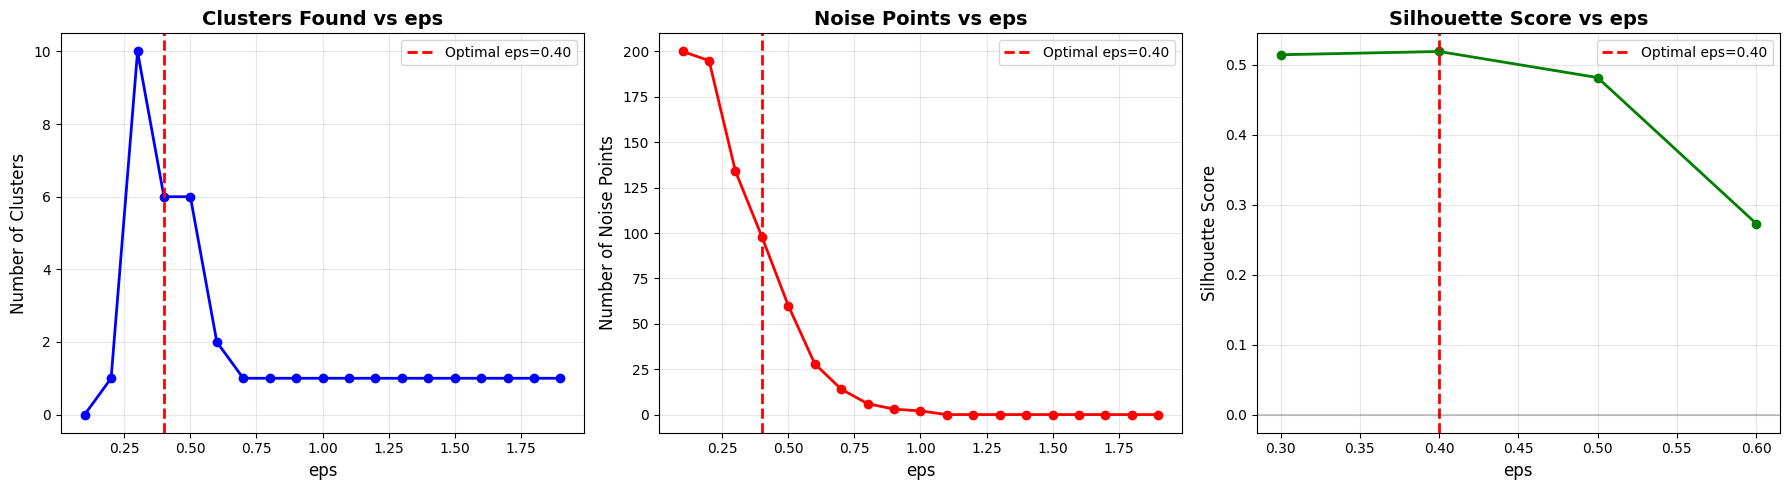

  DBSCAN optimal eps: 0.400
  Hierarchical using k: 6


In [4]:
print("\nFinding optimal parameters...")

# K-Means: Find optimal k
kmeans_temp = SKLearnKMeans(random_state=42)
kmeans_results = kmeans_temp.find_optimal_k(X_scaled, k_range=range(2, 11), method='both', show_plot=True)
optimal_k = kmeans_results['silhouette_k']
print(f"  K-Means optimal k: {optimal_k}")

# DBSCAN: Find optimal eps
dbscan_temp = SKLearnDBSCAN(min_samples=5)
dbscan_results = dbscan_temp.find_optimal_eps(X_scaled, eps_range=np.arange(0.1, 2.0, 0.1), show_plot=True)
optimal_eps = dbscan_results['optimal_eps']
print(f"  DBSCAN optimal eps: {optimal_eps:.3f}")

# Hierarchical: Use same k as K-Means
print(f"  Hierarchical using k: {optimal_k}")

## Train All Models

In [6]:
models = {
    'K-Means': SKLearnKMeans(n_clusters=optimal_k, random_state=42),
    'DBSCAN': SKLearnDBSCAN(eps=optimal_eps, min_samples=5),
    'Hierarchical': SKLearnHierarchicalClustering(n_clusters=optimal_k, linkage='ward')
}

results = {
    'Model': [],
    'N Clusters': [],
    'Silhouette': [],
    'N Noise': []
}

print("\nTraining models...")
for name, model in models.items():
    # Train
    model.fit(X_scaled)
    labels = model.predict(X_scaled)
    
    # Count clusters and noise
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)
    
    # Calculate metrics
    silhouette = model.silhouette_score(X_scaled, exclude_noise=True)
    
    # Store
    results['Model'].append(name)
    results['N Clusters'].append(n_clusters)
    results['Silhouette'].append(silhouette)
    results['N Noise'].append(n_noise)
    
    print(f"  {name}: Clusters={n_clusters}, Silhouette={silhouette:.4f}")


Training models...
  K-Means: Clusters=6, Silhouette=0.4311
  DBSCAN: Clusters=6, Silhouette=0.5190
  Hierarchical: Clusters=6, Silhouette=0.4201


## Compare Results


Model Comparison (sorted by Silhouette):
          Model  N Clusters  Silhouette  N Noise
1        DBSCAN           6    0.519023       98
0       K-Means           6    0.431065        0
2  Hierarchical           6    0.420117        0


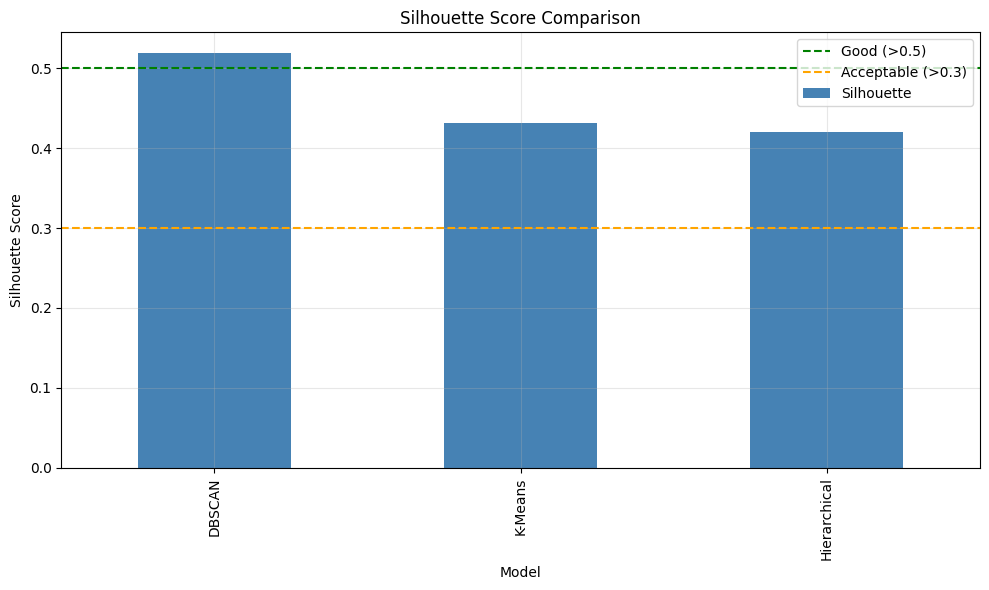

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Silhouette', ascending=False)

print("\nModel Comparison (sorted by Silhouette):")
print(results_df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

results_df.plot(x='Model', y='Silhouette', kind='bar', ax=ax, color='steelblue')
ax.set_title('Silhouette Score Comparison')
ax.set_ylabel('Silhouette Score')
ax.axhline(y=0.5, color='g', linestyle='--', label='Good (>0.5)')
ax.axhline(y=0.3, color='orange', linestyle='--', label='Acceptable (>0.3)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Visualize Clusters (PCA)

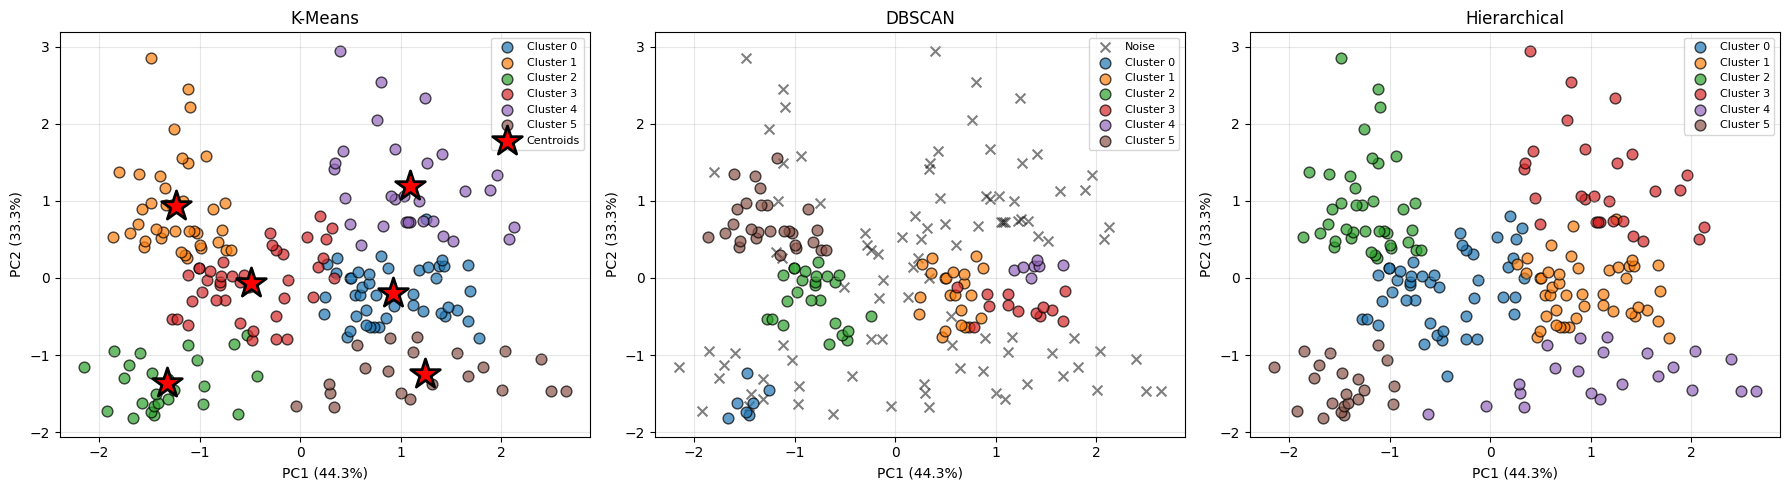

In [17]:
pca = SKLearnPCA(n_components=2)
pca.fit(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    labels = model.predict(X_scaled)
    
    # Plot clusters
    ax = axes[idx]
    X_pca = pca.transform(X_scaled)
    
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for label in unique_labels:
        if label == -1:
            # Noise
            mask = labels == label
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c='black', marker='x', s=50, alpha=0.5, label='Noise')
        else:
            mask = labels == label
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=[colors[label]], marker='o', s=60, alpha=0.7,
                      edgecolors='black', linewidths=1, label=f'Cluster {label}')
    
    # Add centroids for K-Means
    if hasattr(model, 'cluster_centers_'):
        centers_pca = pca.transform(model.cluster_centers_)
        ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
                  c='red', marker='*', s=500, edgecolors='black',
                  linewidths=2, label='Centroids', zorder=10)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{name}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusions

In [18]:
best_model = results_df.iloc[0]

print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)
print(f"Best model: {best_model['Model']}")
print(f"  Silhouette Score: {best_model['Silhouette']:.4f}")
print(f"  Clusters Found: {best_model['N Clusters']}")
if best_model['N Noise'] > 0:
    print(f"  Noise Points: {best_model['N Noise']}")


FINAL CONCLUSIONS
Best model: DBSCAN
  Silhouette Score: 0.5190
  Clusters Found: 6
  Noise Points: 98
